In [14]:
# ── Parámetros a ajustar manualmente ──────────────────────────────────────────
P0_BINARY   = 0.05
P1_BINARY   = 150
P0_RRLYRAE  = 0.15
P1_RRLYRAE  = 1.0
P0_CEFEID   = 0.2
P1_CEFEID   = 150
P_NUM       = 10000
N_SAMPLE    = 5
RANDOM_SEED = 2404

ACTIVE_TYPES    = ["binary"]  # Subconjunto a procesar ("binary", "rrlyrae", "cefeid")
PLOT_ENTROPIES  = True  # Graficar periodograma de entropía, se recomienda solo con N_SAMPLE pequeños
PLOT_LIGHTCURVE = True  # Graficar curva de luz de la mejor solución

# ── Divisiones de grilla por tipo (t_parts=fases, u_parts=magnitudes) ─────────
GRID_PARTS = {
    "binary":  {"t_parts": 7, "u_parts": 7},
    "rrlyrae": {"t_parts": 7, "u_parts": 7},
    "cefeid":  {"t_parts": 10, "u_parts": 10},
}
# ──────────────────────────────────────────────────────────────────────────────

In [15]:
# Seleccionar algoritmo de mínima entropía
import least_entropy_antialiasing_typed_phased as le


Procesando: BINARY
  Muestra: 5 de 10 archivos disponibles


binary:   0%|          | 0/5 [00:00<?, ?it/s]

  [SKIP] OGLE-LMC-ECL-30429 — p_true=184.0403 fuera de [0.05, 150]


100%|██████████| 5962/5962 [00:09<00:00, 647.18it/s]


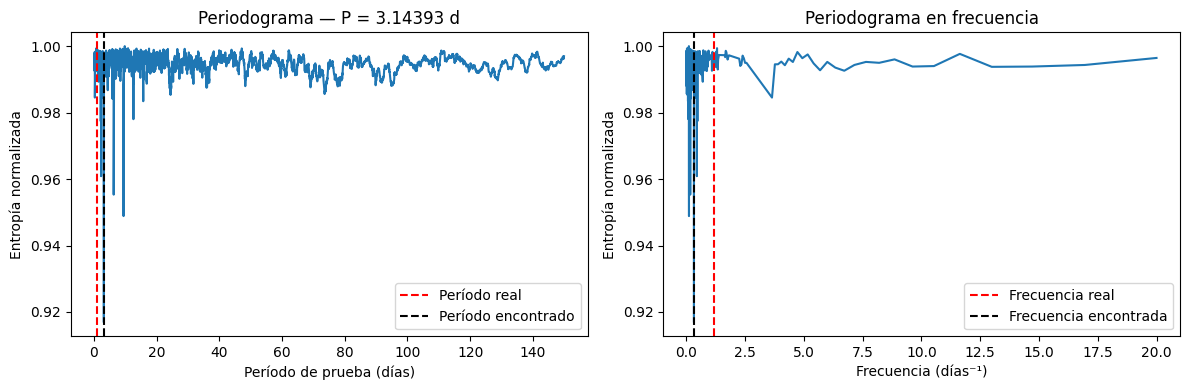

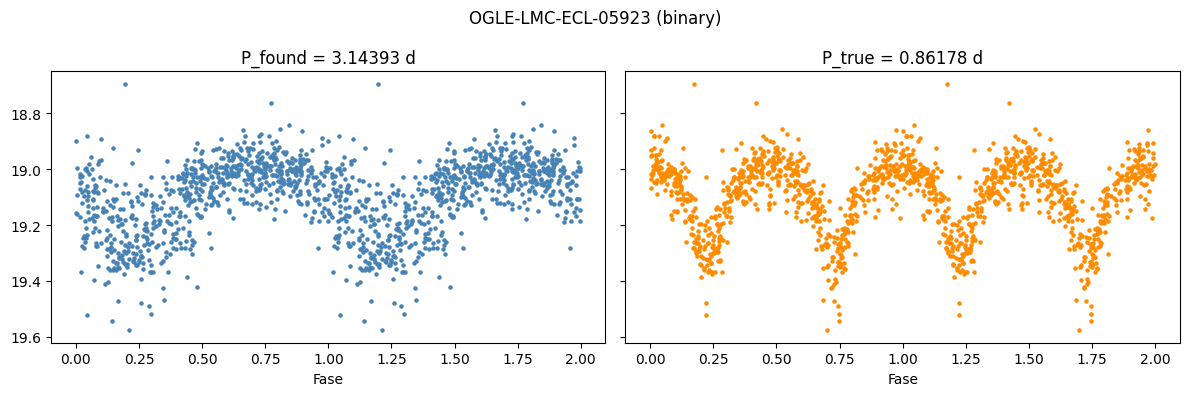

100%|██████████| 5917/5917 [00:09<00:00, 626.65it/s]]


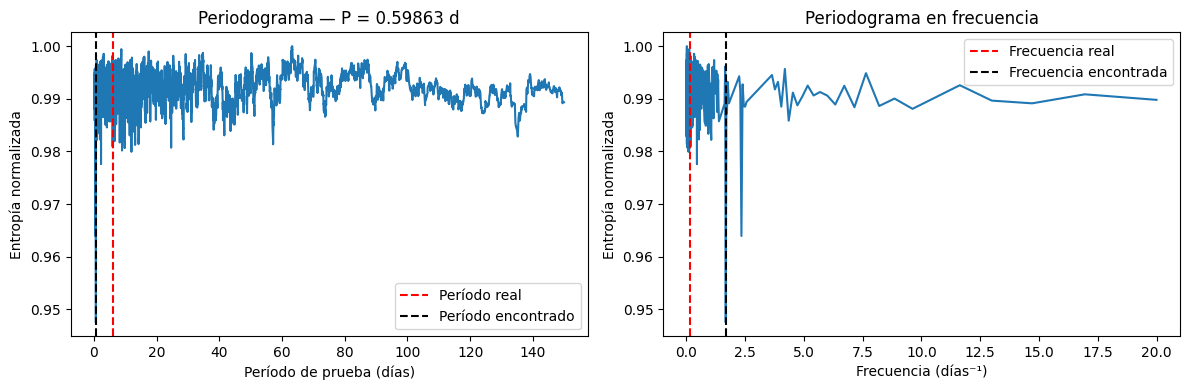

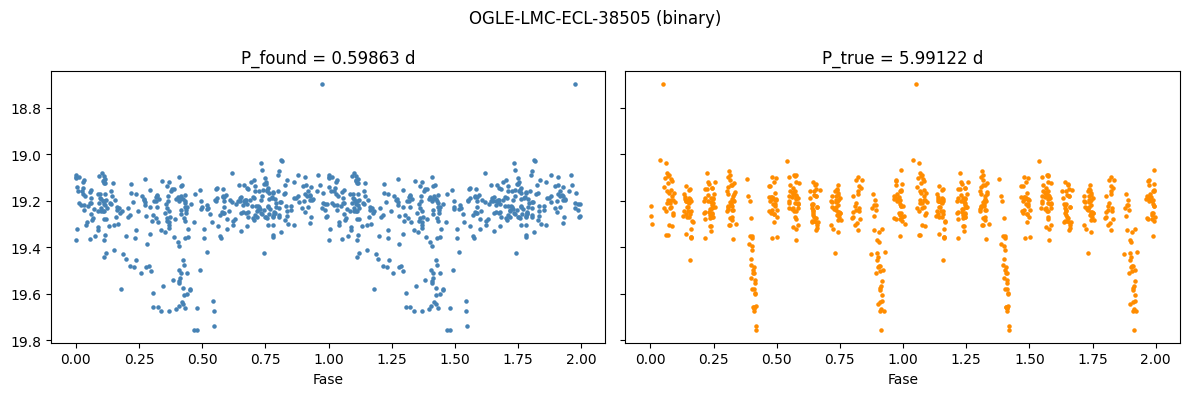

100%|██████████| 5907/5907 [00:09<00:00, 619.95it/s]]


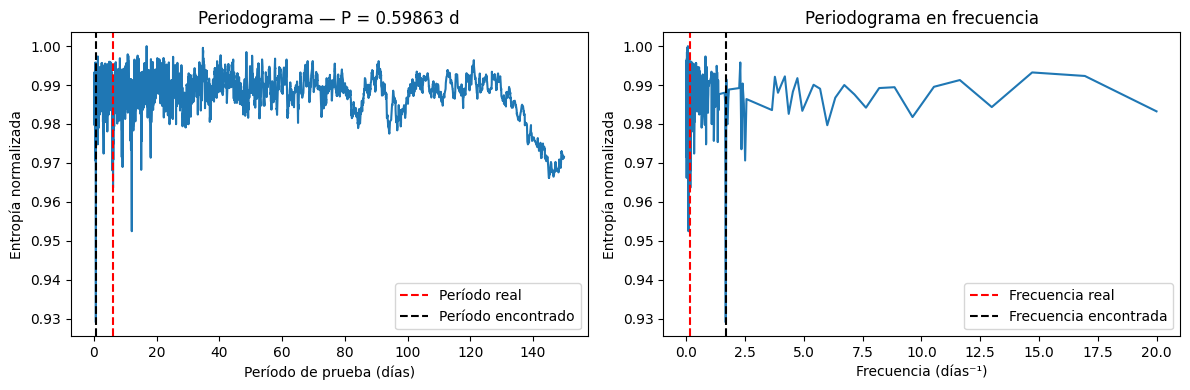

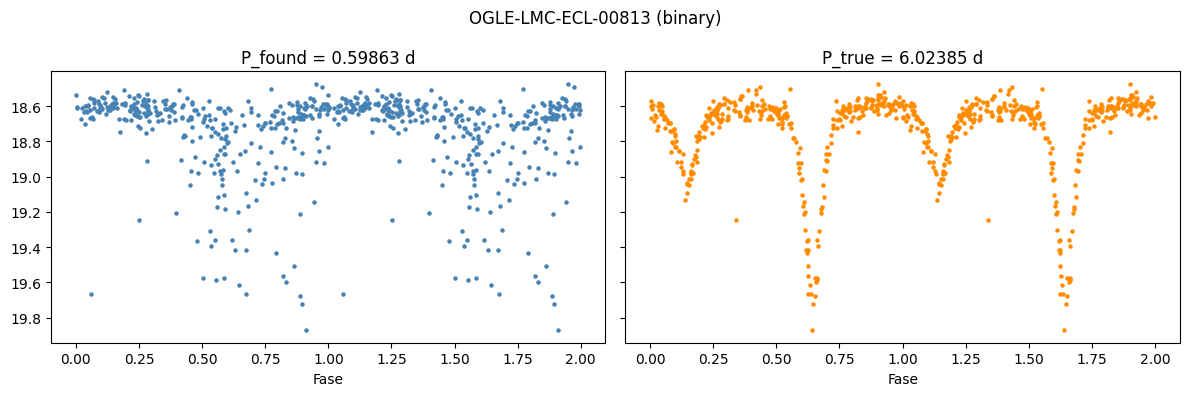

100%|██████████| 5936/5936 [00:09<00:00, 627.48it/s]]


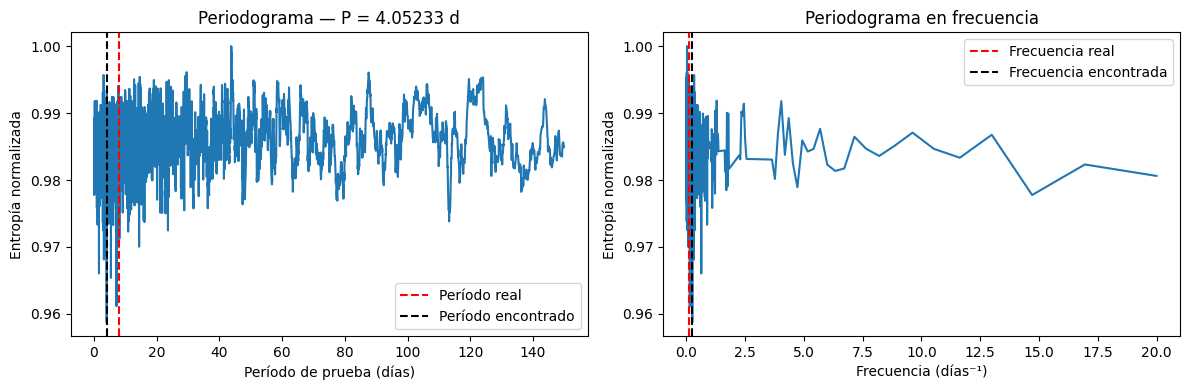

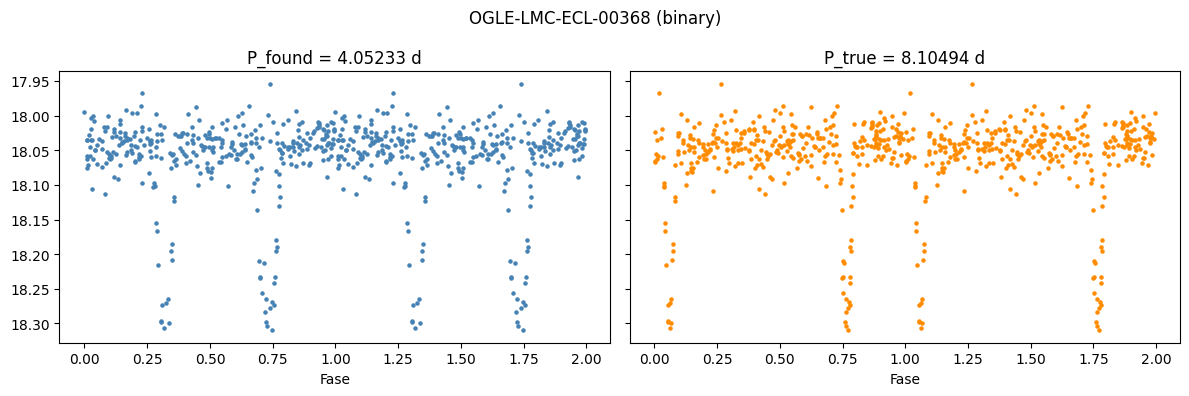

binary: 100%|██████████| 5/5 [00:41<00:00,  8.39s/it]


Listo. Resultados en df_results.
tipo
binary    0.25
Name: recovery_rate, dtype: float64


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import testing as tst
import random
from datetime import datetime

COLLECTIONS = {
    "binary": {
        "dat_dir":  "ogle_collection/binaries_phot",
        "ref_file": "ogle_collection/binaries.txt",
        "p_col":    "P",
        "star_type": "binary",
        "p0": P0_BINARY,
        "p1": P1_BINARY,
    },
    "rrlyrae": {
        "dat_dir":  "ogle_collection/rrlyrae_phot",
        "ref_file": "ogle_collection/rrlyrae.txt",
        "p_col":    "P_1",
        "star_type": "rrlyrae",
        "p0": P0_RRLYRAE,
        "p1": P1_RRLYRAE,
    },
    "cefeid": {
        "dat_dir":  "ogle_collection/classical_cefeids_phot",
        "ref_file": "ogle_collection/classical_cefeids.txt",
        "p_col":    "P_1",
        "star_type": "cefeid",
        "p0": P0_CEFEID,
        "p1": P1_CEFEID,
    },
}


def load_reference(ref_file, p_col):
    df_ref = pd.read_csv(ref_file, skiprows=6, sep=r"\s+")
    ref = {}
    for _, row in df_ref.iterrows():
        ref[str(row["ID"])] = {
            "mag_I":  row["I"],
            "p_true": row[p_col],
        }
    return ref


def plot_lightcurve(data, phases_found_1, phases_found_2,
                    best_period, true_period,
                    nombre, star_type):

    # fases con período encontrado
    phases_found = np.concatenate([phases_found_1, phases_found_2])
    mags_found   = np.concatenate([data["u"], data["u"]])

    # fases con período real
    phases_true = (data["t"] % true_period) / true_period
    phases_true = np.concatenate([phases_true, phases_true+1])
    mags_true   = np.concatenate([data["u"], data["u"]])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # curva con período encontrado
    axes[0].scatter(phases_found, mags_found, s=5, color="steelblue")
    axes[0].set_title(f"P_found = {best_period:.5f} d")
    axes[0].set_xlabel("Fase")
    axes[0].invert_yaxis()

    # curva con período real
    axes[1].scatter(phases_true, mags_true, s=5, color="darkorange")
    axes[1].set_title(f"P_true = {true_period:.5f} d")
    axes[1].set_xlabel("Fase")

    fig.suptitle(f"{nombre} ({star_type})")
    plt.tight_layout()
    plt.show()


# ── Validar ACTIVE_TYPES ──────────────────────────────────────────────────────
invalid = set(ACTIVE_TYPES) - set(COLLECTIONS)
if invalid:
    raise ValueError(f"Tipos no reconocidos en ACTIVE_TYPES: {invalid}")

# ── Bucle principal ───────────────────────────────────────────────────────────
all_results = []

for tipo, cfg in COLLECTIONS.items():
    if tipo not in ACTIVE_TYPES:
        continue

    print(f"\n{'='*50}")
    print(f"Procesando: {tipo.upper()}")
    print(f"{'='*50}")

    try:
        ref = load_reference(cfg["ref_file"], cfg["p_col"])
    except Exception as e:
        print(f"  [ERROR] No se pudo cargar la referencia {cfg['ref_file']}: {e}")
        continue

    archivos = [f for f in os.listdir(cfg["dat_dir"]) if f.endswith(".dat")]


    if N_SAMPLE is not None and N_SAMPLE < len(archivos):
        rng = random.Random(RANDOM_SEED)
        archivos = rng.sample(archivos, N_SAMPLE)
        print(f"  Muestra: {N_SAMPLE} de {len(archivos) + N_SAMPLE} archivos disponibles")
    else:
        print(f"  Procesando todos los archivos: {len(archivos)}")

    for archivo in tqdm(archivos, desc=tipo):
        nombre = archivo.split(".")[0]
        ruta   = os.path.join(cfg["dat_dir"], archivo)

        if nombre not in ref:
            print(f"  [WARN] {nombre} no encontrado en {cfg['ref_file']}, omitiendo.")
            continue

        p_true = ref[nombre]["p_true"]
        mag_I  = ref[nombre]["mag_I"]

        # Verificar que el período real esté dentro del rango de búsqueda
        if not (cfg["p0"] <= p_true <= cfg["p1"]):
            print(f"  [SKIP] {nombre} — p_true={p_true:.4f} fuera de [{cfg['p0']}, {cfg['p1']}]")
            continue

        try:
            data = pd.read_csv(ruta, sep=" ", lineterminator="\n", names=("t", "u", "inc_u"))
        except Exception as e:
            print(f"  [ERROR] {nombre} — no se pudo leer el .dat: {e}")
            continue

        try:
            p_found, min_entropy, phases1, phases2 = le.find_best_period(
                data,
                p0=cfg["p0"], p1=cfg["p1"],
                p_num=P_NUM,
                star_type=cfg["star_type"],
                t_parts=GRID_PARTS[tipo]["t_parts"],
                u_parts=GRID_PARTS[tipo]["u_parts"],
                plot_entropies=PLOT_ENTROPIES,
                eps=0,
                plot_periods=False,
                p_teo = p_true
            )
        except Exception as e:
            print(f"  [ERROR] {nombre} — fallo en find_best_period: {e}")
            continue

        if PLOT_LIGHTCURVE:
            plot_lightcurve(
                data,
                phases1, phases2,
                p_found,
                p_true,
                nombre,
                tipo
            )

        error    = tst.period_error(p_found, p_true)
        multiple = tst.which_multiple(p_found, p_true)

        all_results.append({
            "id":       nombre,
            "tipo":     tipo,
            "mag_I":    mag_I,
            "p_true":   p_true,
            "p_found":  p_found,
            "error":    error,
            "multiple": multiple,
            "success":  error < 0.05,
        })

df_results = pd.DataFrame(all_results)
print("\nListo. Resultados en df_results.")
print(df_results.groupby("tipo")["success"].mean().rename("recovery_rate"))

In [17]:
#Exportar resultados
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("resultados_masivos", exist_ok=True)

# ── Resultados ────────────────────────────────────────────────────────────────
df_results.to_csv(f"resultados_masivos/resultados_{timestamp}.csv", index=False)

# ── Parámetros ────────────────────────────────────────────────────────────────
params = {
    "timestamp":      timestamp,
    "P0_BINARY":      P0_BINARY,
    "P1_BINARY":      P1_BINARY,
    "P0_RRLYRAE":     P0_RRLYRAE,
    "P1_RRLYRAE":     P1_RRLYRAE,
    "P0_CEFEID":      P0_CEFEID,
    "P1_CEFEID":      P1_CEFEID,
    "P_NUM":          P_NUM,
    "N_SAMPLE":       N_SAMPLE,
    "RANDOM_SEED":    RANDOM_SEED,
    "ACTIVE_TYPES":   str(ACTIVE_TYPES),
    "PLOT_ENTROPIES": PLOT_ENTROPIES,
    "PLOT_LIGHTCURVE":PLOT_LIGHTCURVE,
}
pd.DataFrame([params]).to_csv(f"resultados_masivos/params_{timestamp}.csv", index=False)

print(f"Guardado en: resultados_masivos/resultados_{timestamp}.csv")
print(f"Parámetros en: resultados_masivos/params_{timestamp}.csv")

Guardado en: resultados_masivos/resultados_20260424_103128.csv
Parámetros en: resultados_masivos/params_20260424_103128.csv


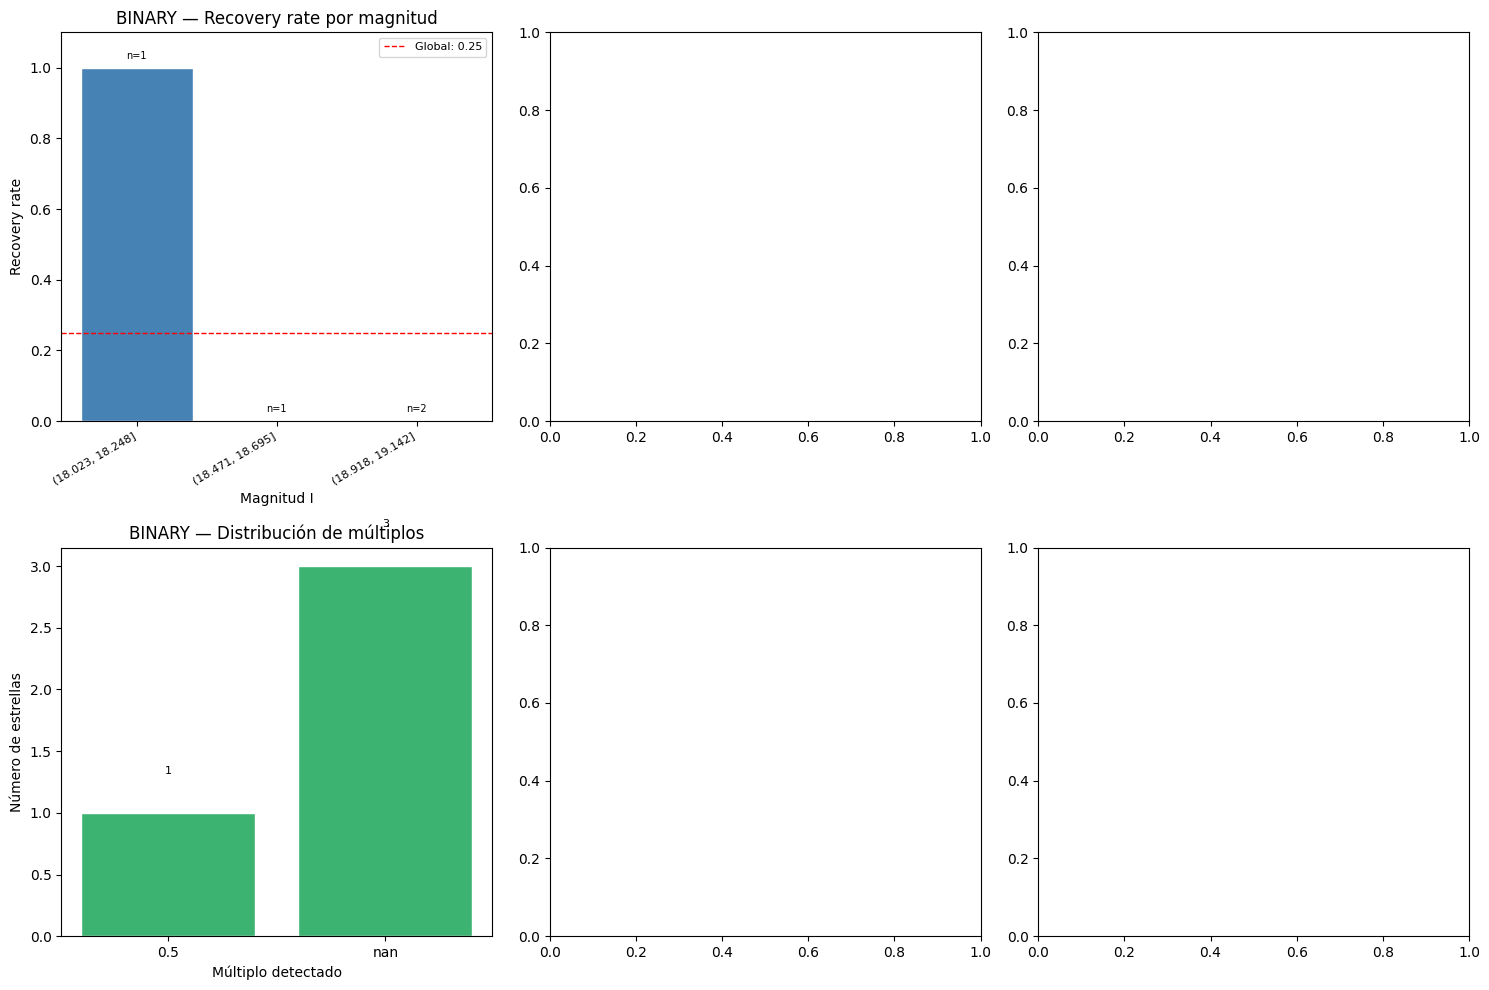

Gráficas guardadas en: resultados_masivos/recovery_bars_20260424_103128.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
tipos = ACTIVE_TYPES

for col, tipo in enumerate(tipos):
    df_tipo = df_results[df_results["tipo"] == tipo]

    # ── Recovery rate por bin de magnitud ────────────────────────────────
    ax_mag = axes[0, col]
    bins = pd.cut(df_tipo["mag_I"], bins=5)
    recovery = df_tipo.groupby(bins, observed=True)["success"].mean()
    counts   = df_tipo.groupby(bins, observed=True)["success"].count()

    x     = range(len(recovery))
    bars  = ax_mag.bar(x, recovery.values, color="steelblue", edgecolor="white")
    ax_mag.set_xticks(x)
    ax_mag.set_xticklabels([str(b) for b in recovery.index], rotation=30, ha="right", fontsize=8)
    ax_mag.set_ylim(0, 1.1)
    ax_mag.set_xlabel("Magnitud I")
    ax_mag.set_ylabel("Recovery rate")
    ax_mag.set_title(f"{tipo.upper()} — Recovery rate por magnitud")
    ax_mag.axhline(df_tipo["success"].mean(), color="red", linestyle="--", linewidth=1, label=f"Global: {df_tipo['success'].mean():.2f}")
    ax_mag.legend(fontsize=8)

    # Anotar n en cada barra
    for bar, n in zip(bars, counts.values):
        ax_mag.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"n={n}", ha="center", va="bottom", fontsize=7)

    # ── Distribución de múltiplos ─────────────────────────────────────────
    ax_mul = axes[1, col]
    mul_counts = df_tipo["multiple"].value_counts(dropna=False).sort_index()

    # Separar éxitos (múltiplo identificado) de fallos (None)
    labels = [str(m) if m is not None else "Fallo" for m in mul_counts.index]
    colors = ["salmon" if l == "Fallo" else "mediumseagreen" for l in labels]

    ax_mul.bar(labels, mul_counts.values, color=colors, edgecolor="white")
    ax_mul.set_xlabel("Múltiplo detectado")
    ax_mul.set_ylabel("Número de estrellas")
    ax_mul.set_title(f"{tipo.upper()} — Distribución de múltiplos")

    for i, (label, val) in enumerate(zip(labels, mul_counts.values)):
        ax_mul.text(i, val + 0.3, str(val), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"resultados_masivos/recovery_bars_{timestamp}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráficas guardadas en: resultados_masivos/recovery_bars_{timestamp}.png")